In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from networkx.algorithms.community import greedy_modularity_communities

In [3]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 500)

In [4]:
# connections file path
df = pd.read_csv("data/Connections.csv")
assert df is not None, "File not found!"

In [5]:
df = df.sample(n=150, random_state=42)

In [6]:
df.head()

,First Name,Last Name,URL,Email Address,Company,Position,Connected On
268,Iman,Thiyanga,https://www.linkedin.com/in/iman-thiyanga,NaN,HexDive Technologies,Associate Software Engineer,6-Feb-24
73,Dilshi,Tharundi,https://www.linkedin.com/in/dilshi-tharundi-33...,NaN,Pekoe,Software Engineer,13-Nov-24
289,Theoda,Hettiarachchi,https://www.linkedin.com/in/theoda-hettiarachc...,NaN,Creative Software,Software Engineering Intern,25-Jan-24
155,Savandi,Kodithuwakku,https://www.linkedin.com/in/savandi-kodithuwakku,NaN,IoT and Embedded Systems Research Labs - Facul...,Web Developer,20-Jul-24
104,Kokila,Nethmini,https://www.linkedin.com/in/kokila-nethmini2000,NaN,Techorin,Software Engineer Intern,2-Oct-24


In [7]:
G = nx.Graph()

ME = "Me"
G.add_node(ME)

for _, row in df.iterrows():
    person = f"{row['First Name']} {row['Last Name']}"
    G.add_node(person)
    G.add_edge(ME, person)

In [8]:
for company, group in df.groupby("Company"):
    people = [
        f"{row['First Name']} {row['Last Name']}" 
        for _, row in group.iterrows()
    ]
    for i in range(len(people)):
        for j in range(i + 1, len(people)):
            G.add_edge(people[i], people[j])
            
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 150
Number of edges: 175


In [9]:
# Node-level measures - Degree Centrality

degree = dict(G.degree())
degree_centrality = nx.degree_centrality(G)

pd.DataFrame({
    "node": degree.keys(),
    "degree": degree.values(),
    "degree_centrality": degree_centrality.values()
}).sort_values("degree_centrality", ascending=False)

,node,degree,degree_centrality
0,Me,149,1.000000
45,Supipi Meddegodage,4,0.026846
90,Neranji Abeysekara,4,0.026846
95,Janani Siriwardane,4,0.026846
124,Ridmi Abeysiri,4,0.026846
...,...,...,...
143,Isura Perera,1,0.006711
145,Tharuka Wijethunga,1,0.006711
144,Raveesha Induwara,1,0.006711
146,Reezma Hanan,1,0.006711


In [10]:
# Node-level measures - Closeness Centrality
 
closeness = nx.closeness_centrality(G)

pd.DataFrame({
    "node": closeness.keys(),
    "closeness": closeness.values()
}).sort_values("closeness", ascending=False)

,node,closeness
0,Me,1.000000
45,Supipi Meddegodage,0.506803
90,Neranji Abeysekara,0.506803
95,Janani Siriwardane,0.506803
124,Ridmi Abeysiri,0.506803
...,...,...
143,Isura Perera,0.501684
145,Tharuka Wijethunga,0.501684
144,Raveesha Induwara,0.501684
146,Reezma Hanan,0.501684


In [11]:
# Node-level measures - Betweenness Centrality

betweenness = nx.betweenness_centrality(G, normalized=True)

pd.DataFrame({
    "node": betweenness.keys(),
    "betweeness": betweenness.values()
}).sort_values("betweeness", ascending=False)

,node,betweeness
0,Me,0.997642
1,Iman Thiyanga,0.000000
2,Dilshi Tharundi,0.000000
3,Theoda Hettiarachchi,0.000000
4,Savandi Kodithuwakku,0.000000
...,...,...
145,Tharuka Wijethunga,0.000000
146,Reezma Hanan,0.000000
147,Lahiru Praveen,0.000000
148,Dasun Theekshana,0.000000


In [12]:
# Node-level measures - Eigenvector Centrality

eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

pd.DataFrame({
    "node": eigenvector.keys(),
    "eigenvector": eigenvector.values()
}).sort_values("eigenvector", ascending=False)

,node,eigenvector
0,Me,0.700496
45,Supipi Meddegodage,0.074465
90,Neranji Abeysekara,0.074465
95,Janani Siriwardane,0.074465
124,Ridmi Abeysiri,0.074465
...,...,...
143,Isura Perera,0.056459
145,Tharuka Wijethunga,0.056459
144,Raveesha Induwara,0.056459
146,Reezma Hanan,0.056459


In [13]:
# Node-level measures - Local Clustering Coefficient

clustering = nx.clustering(G)

pd.DataFrame({
    "node": clustering.keys(),
    "clustering_coefficient": clustering.values()
}).sort_values("clustering_coefficient", ascending=False)

,node,clustering_coefficient
5,Kokila Nethmini,1.0
3,Theoda Hettiarachchi,1.0
14,Hiruni Praveesha Perera,1.0
16,Mohamed Shamil,1.0
123,Sajini Meddawela,1.0
...,...,...
143,Isura Perera,0.0
145,Tharuka Wijethunga,0.0
144,Raveesha Induwara,0.0
146,Reezma Hanan,0.0


In [14]:
df_metrics = pd.DataFrame({
    "node": G.nodes(),
    "degree": [degree[n] for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "clustering_coefficient": [clustering[n] for n in G.nodes()],
})

df_metrics.sort_values("eigenvector", ascending=False)

,node,degree,degree_centrality,closeness,betweenness,eigenvector,clustering_coefficient
0,Me,149,1.000000,1.000000,0.997642,0.700496,0.002358
45,Supipi Meddegodage,4,0.026846,0.506803,0.000000,0.074465,1.000000
90,Neranji Abeysekara,4,0.026846,0.506803,0.000000,0.074465,1.000000
95,Janani Siriwardane,4,0.026846,0.506803,0.000000,0.074465,1.000000
124,Ridmi Abeysiri,4,0.026846,0.506803,0.000000,0.074465,1.000000
...,...,...,...,...,...,...,...
143,Isura Perera,1,0.006711,0.501684,0.000000,0.056459,0.000000
145,Tharuka Wijethunga,1,0.006711,0.501684,0.000000,0.056459,0.000000
144,Raveesha Induwara,1,0.006711,0.501684,0.000000,0.056459,0.000000
146,Reezma Hanan,1,0.006711,0.501684,0.000000,0.056459,0.000000


In [15]:
# Most Influential Person based on Eigenvector

df_metrics.sort_values("eigenvector", ascending=False).head(1)

,node,degree,degree_centrality,closeness,betweenness,eigenvector,clustering_coefficient
0,Me,149,1.0,1.0,0.997642,0.700496,0.002358


In [16]:
# Bridge Node

df_metrics.sort_values("betweenness", ascending=False).head(1)

,node,degree,degree_centrality,closeness,betweenness,eigenvector,clustering_coefficient
0,Me,149,1.0,1.0,0.997642,0.700496,0.002358


In [17]:
# Network Tightness (tightly connected or loosely connected)

df_metrics["clustering_coefficient"].mean()

np.float64(0.2333490537517383)

In [18]:
# Centralized or Distributed

degree_centrality[ME]

1.0

In [19]:
communities = list(greedy_modularity_communities(G))

# Show community sizes
[(i+1, len(c)) for i, c in enumerate(communities)]


[(1, 115),
 (2, 4),
 (3, 3),
 (4, 3),
 (5, 3),
 (6, 2),
 (7, 2),
 (8, 2),
 (9, 2),
 (10, 2),
 (11, 2),
 (12, 2),
 (13, 2),
 (14, 2),
 (15, 2),
 (16, 2)]

C:\Users\anner\AppData\Local\Temp\ipykernel_39344\2056134102.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(communities))


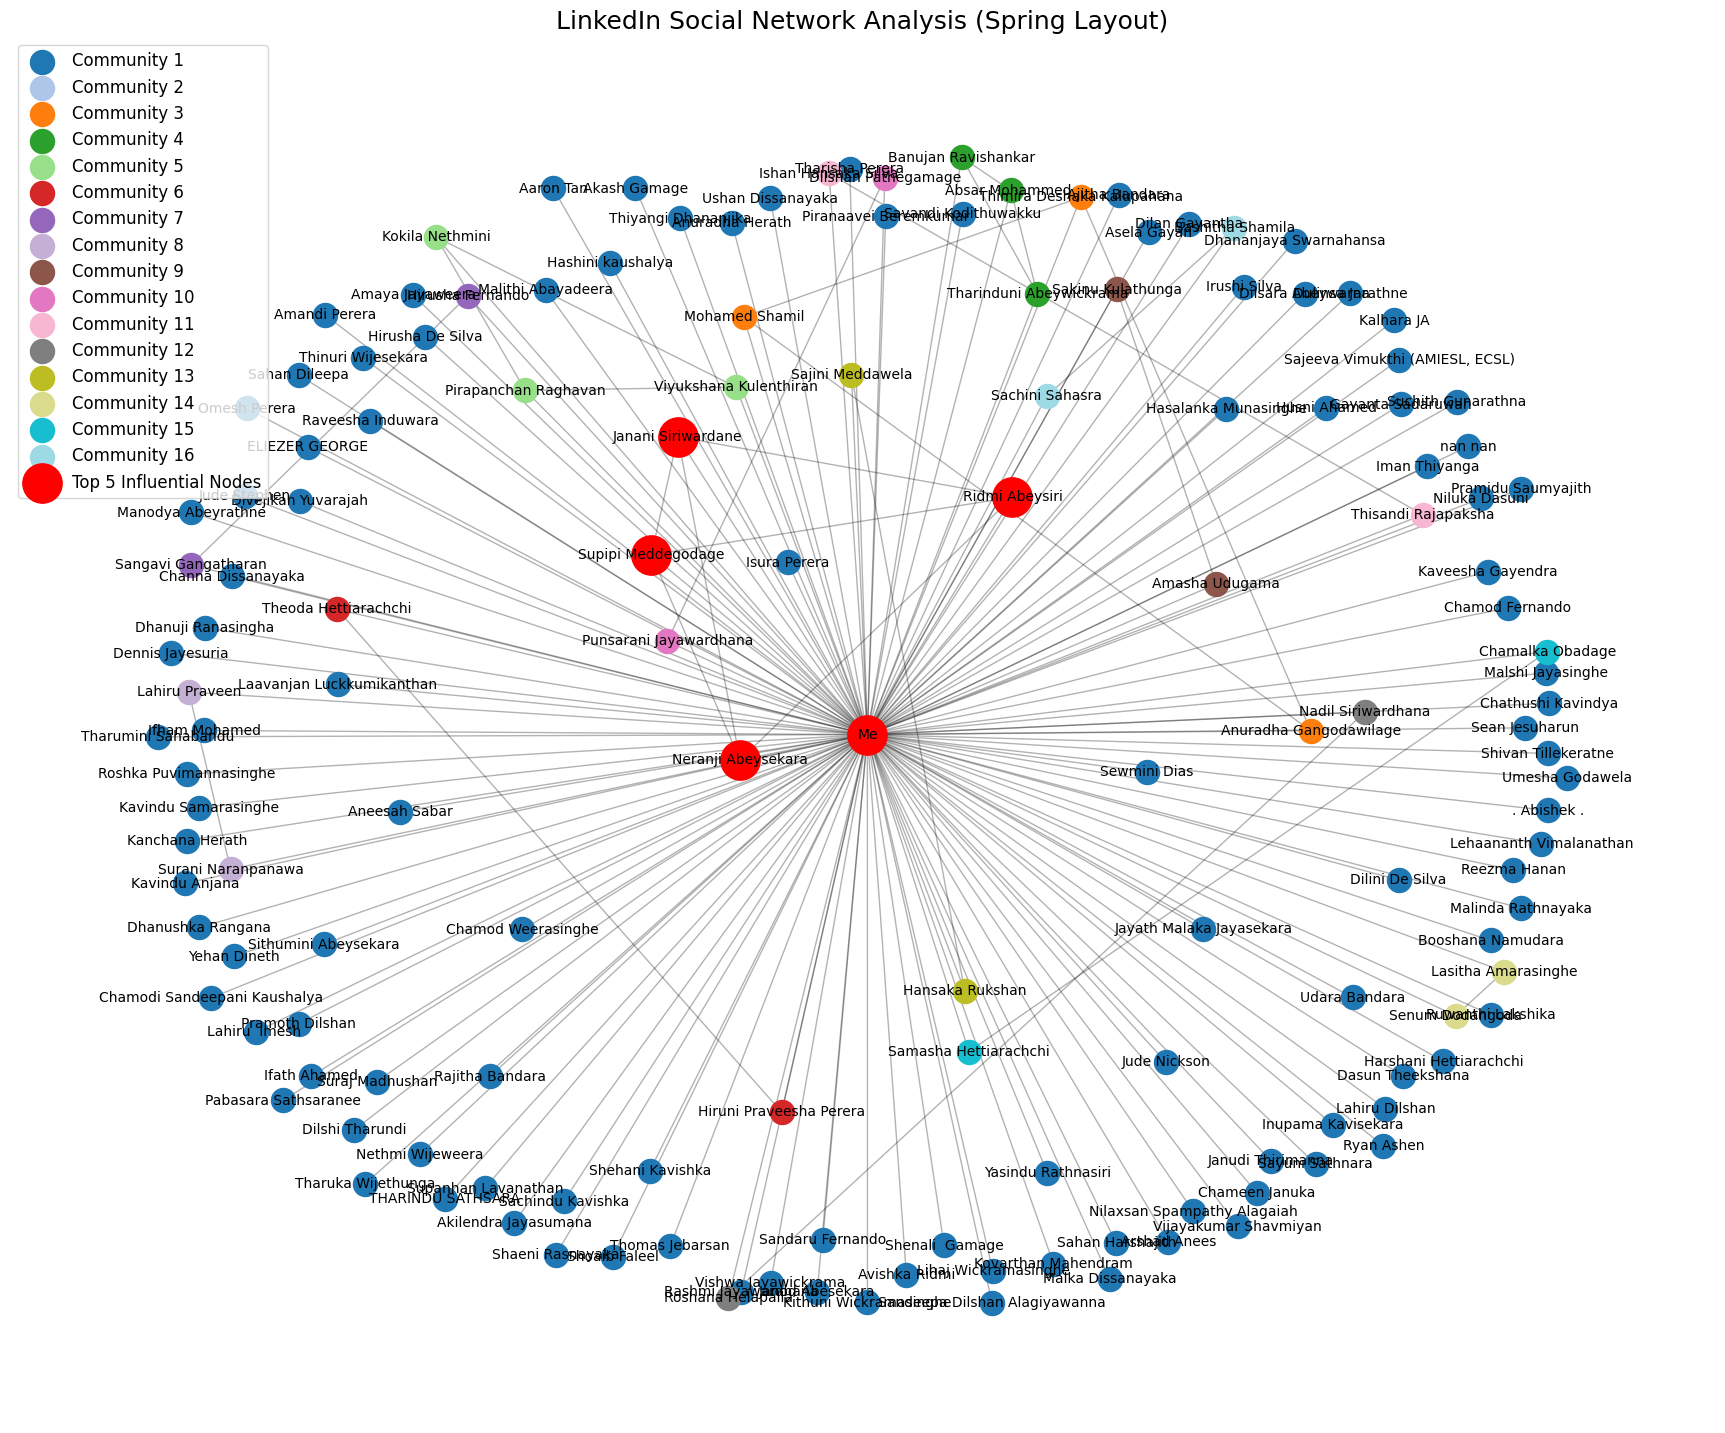

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

top5 = df_metrics.sort_values("eigenvector", ascending=False).head(5)["node"]

pos = nx.spring_layout(G, seed=42, k=0.8)

plt.figure(figsize=(22, 18))

# Create a color map
cmap = cm.get_cmap("tab20", len(communities))

# Draw communities with different colors
for i, comm in enumerate(communities):
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=list(comm),
        node_size=300,
        node_color=[cmap(i)],
        label=f"Community {i+1}"
    )

# Highlight top 5 influential nodes
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=top5,
    node_color="red",
    node_size=800,
    label="Top 5 Influential Nodes"
)

nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("LinkedIn Social Network Analysis (Spring Layout)", fontsize=18)
plt.legend(fontsize=12, loc="best")
plt.axis("off")
plt.savefig("figures/linkedin_sna.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
top_node = df_metrics.sort_values("eigenvector", ascending=False).iloc[0]["node"]

G_removed = G.copy()
G_removed.remove_node(top_node)

print("Connected components BEFORE removal:", nx.number_connected_components(G))
print("Connected components AFTER removal:", nx.number_connected_components(G_removed))


Connected components BEFORE removal: 1
Connected components AFTER removal: 129


C:\Users\anner\AppData\Local\Temp\ipykernel_39344\2582688354.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(communities_removed))


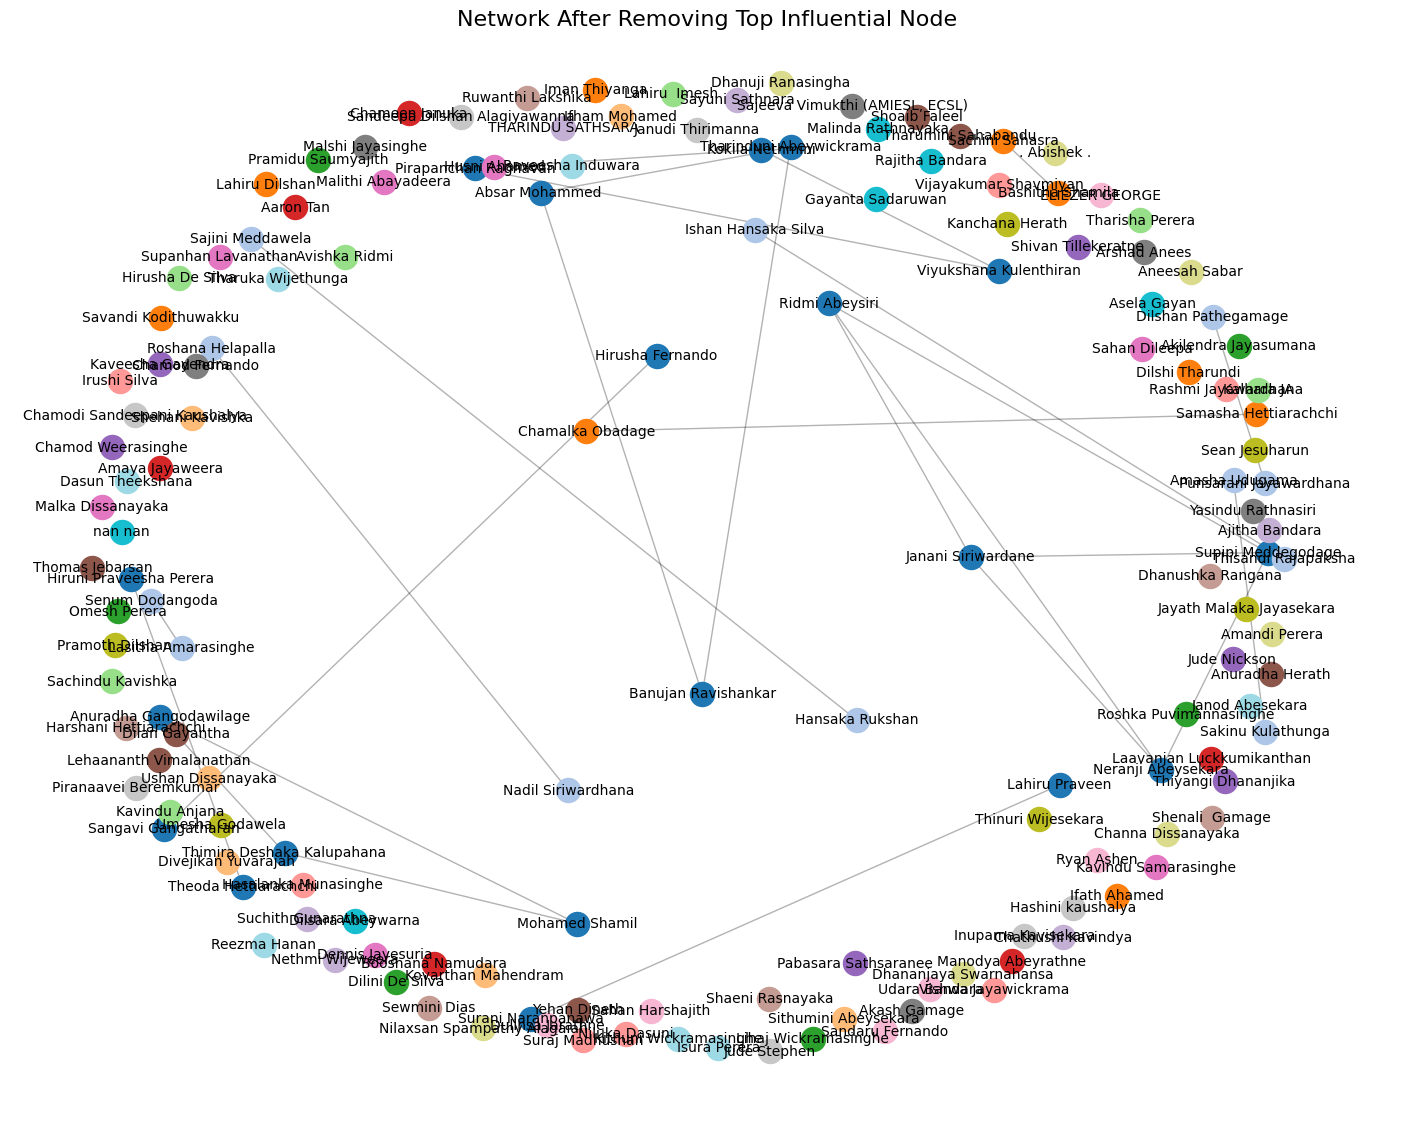

In [22]:
import matplotlib.cm as cm
import networkx as nx
import matplotlib.pyplot as plt

# Recompute communities after removal
communities_removed = list(nx.algorithms.community.greedy_modularity_communities(G_removed))

plt.figure(figsize=(18, 14))
pos_removed = nx.spring_layout(G_removed, seed=42, k=0.8)

# Colormap
cmap = cm.get_cmap("tab20", len(communities_removed))

# Draw communities in different colors
for i, comm in enumerate(communities_removed):
    nx.draw_networkx_nodes(
        G_removed,
        pos_removed,
        nodelist=list(comm),
        node_size=300,
        node_color=[cmap(i)],
        label=f"Community {i+1}"
    )

nx.draw_networkx_edges(G_removed, pos_removed, alpha=0.3)
nx.draw_networkx_labels(G_removed, pos_removed, font_size=10)

plt.title("Network After Removing Top Influential Node", fontsize=16)
plt.axis("off")
plt.savefig("figures/linkedin_sna_removed.png", dpi=300, bbox_inches="tight")
plt.show()
